<a href="https://colab.research.google.com/github/lucas2905-ship-it/pbd/blob/main/Impacto_de_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando bateria de testes relacionais...

--- RESULTADOS DO EXPERIMENTO (TABELA 1) ---
 Volume (N)  Tempo_Join (ms)
       1000          22.2402
       5000           3.0644
      10000           3.8955
      50000          14.3569
     100000          29.4564
     200000          42.0837

[SUCESSO] Gráfico 'grafico.png' gerado para publicação.


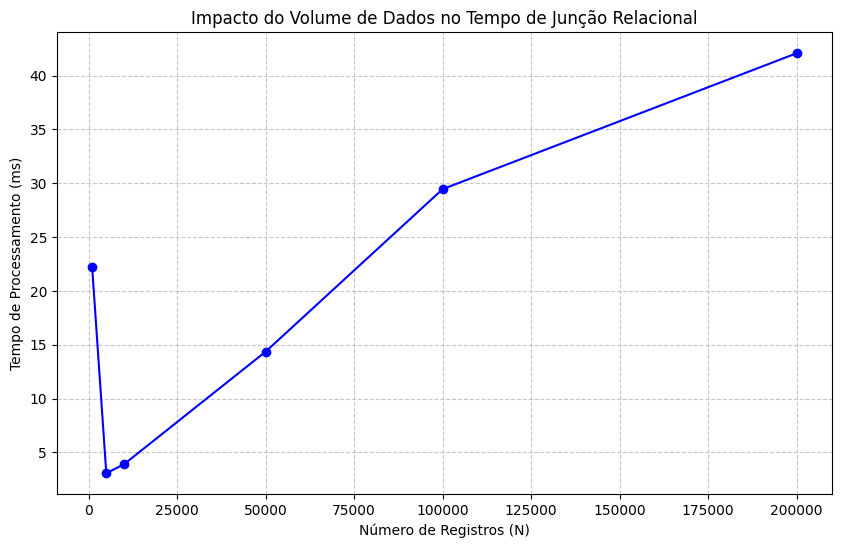

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

def gerar_experimento(n_registros):
    """Gera dados sintéticos e mensura o tempo de junção horizontal."""
    # Criando Tabela de Clientes
    df_clientes = pd.DataFrame({
        'id_cliente': np.arange(n_registros),
        'nome': [f'User_{i}' for i in range(n_registros)],
        'regiao': np.random.choice(['Norte', 'Sul', 'Leste', 'Oeste'], n_registros)
    })

    # Criando Tabela de Vendas (relacionada)
    df_vendas = pd.DataFrame({
        'id_cliente': np.random.randint(0, n_registros, size=n_registros),
        'valor_venda': np.random.uniform(10.0, 500.0, size=n_registros)
    })

    # Mensurando o tempo da junção (Join/Merge)
    inicio = time.time()
    df_resultado = pd.merge(df_clientes, df_vendas, on='id_cliente')
    fim = time.time()

    return round((fim - inicio) * 1000, 4)  # Retorna milissegundos

def executar_ciclo_pesquisa():
    volumes = [1000, 5000, 10000, 50000, 100000, 200000]
    resultados = []

    print("Iniciando bateria de testes relacionais...")
    for v in volumes:
        tempo = gerar_experimento(v)
        resultados.append({'Volume (N)': v, 'Tempo_Join (ms)': tempo})

    # Criar DataFrame de resultados
    df_final = pd.DataFrame(resultados)

    # Exibir Tabela Formatada
    print("\n--- RESULTADOS DO EXPERIMENTO (TABELA 1) ---")
    print(df_final.to_string(index=False))

    # Gerar Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(df_final['Volume (N)'], df_final['Tempo_Join (ms)'], marker='o', linestyle='-', color='b')
    plt.title('Impacto do Volume de Dados no Tempo de Junção Relacional')
    plt.xlabel('Número de Registros (N)')
    plt.ylabel('Tempo de Processamento (ms)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Salvar para o Artigo
    plt.savefig('grafico.png')
    print("\n[SUCESSO] Gráfico 'grafico.png' gerado para publicação.")
    plt.show()

if __name__ == "__main__":
    executar_ciclo_pesquisa()